# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [2]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
!pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


Defaulting to user installation because normal site-packages is not writeable


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [3]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

# TODO A — Framing và Audit dữ liệu

## 1. Bản chất dữ liệu & Ý nghĩa các Feature
- **Một dòng dữ liệu đại diện cho:** Một khách hàng bán buôn (Wholesale Customer), ghi nhận tổng số tiền chi tiêu hàng năm (tính bằng đơn vị tiền tệ nội địa) cho 6 nhóm mặt hàng thực phẩm/tiêu dùng.
- **Các feature chi tiêu (`SPENDING_FEATURES`):**
  - `Fresh`: Mặt hàng tươi sống (rau, củ, quả, thịt tươi...).
  - `Milk`: Sữa và các sản phẩm từ sữa.
  - `Grocery`: Hàng tạp hóa / thực phẩm khô.
  - `Frozen`: Thực phẩm đông lạnh.
  - `Detergents_Paper`: Chất tẩy rửa và sản phẩm từ giấy.
  - `Delicassen`: Thực phẩm chế biến sẵn / đặc sản.
- **Tính hữu ích kinh doanh (Business Utility):** Phân nhóm khách hàng (Customer Segmentation) từ dữ liệu chi tiêu giúp nhà phân phối thiết kế các gói khuyến mãi targeted (Cross-selling/Up-selling), tối ưu hóa tuyến đường giao hàng theo đặc thụ hàng hóa (ví dụ: xe đông lạnh vs xe chở hàng khô), và điều chỉnh chính sách tín dụng/chiết khấu.

## 2. Vai trò của `Channel` và `Region`
- `Channel` (1: Horeca - Hotel/Restaurant/Café, 2: Retail) và `Region` (1: Lisnon, 2: Oporto, 3: Other) là các biến phân loại ngữ cảnh.
- **Tại sao không đưa vào Clustering ban đầu?**
  1. Bài toán yêu cầu phân cụm dựa trên **hành vi chi tiêu thực tế** (Behavioral Segmentation), không phải dựa trên loại hình doanh nghiệp khai báo.
  2. Sự chênh lệch thang đo (binary/categorical vs continuous continuous spending) sẽ làm méo khoảng cách Euclidean/Manhattan trong thuật toán clustering.
  3. `Channel`/`Region` sẽ được giữ lại làm **biến đối chiếu độc lập (External Validation / Context)** sau khi phân cụm xong để kiểm tra tính thực tế.

In [4]:
# --- AUDIT DỮ LIỆU CƠ BẢN ---
print("=== CHECK MISSING VALUES & DUPLICATES ===")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n=== KIỂM TRA SKEWNESS CỦA CÁC BIẾN CHI TIÊU ===")
skewness = X_raw.skew()
display(pd.DataFrame({'Skewness': skewness, 'Requires LogTransform': skewness > 1}))

=== CHECK MISSING VALUES & DUPLICATES ===
Missing values:
Channel             0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
Duplicate rows: 0

=== KIỂM TRA SKEWNESS CỦA CÁC BIẾN CHI TIÊU ===


,Skewness,Requires LogTransform
Fresh,2.56,True
Milk,4.05,True
Grocery,3.59,True
Frozen,5.91,True
Detergents_Paper,3.63,True
Delicassen,11.15,True


# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

## B. Exploratory Data Analysis (EDA)

### Quan sát then chốt từ EDA:
1. **Phân phối:** Tất cả 6 tính năng chi tiêu đều bị lệch phải nặng (Skewness > 1.5). Sự chênh lệch giữa Median và Mean rất lớn (Mean cao hơn hẳn Median), chứng tỏ có các Outlier cực lớn.
2. **Tương quan (Correlation):**
   * Tương quan rất mạnh giữa `Grocery` và `Detergents_Paper` ($r > 0.66$), và giữa `Grocery` với `Milk` ($r > 0.72$). Khách hàng mua nhiều tạp hóa thường mua kèm chất tẩy rửa và sữa (đặc trưng nhóm Retail).
   * `Fresh` và `Frozen` ít tương quan với `Grocery`/`Detergents_Paper`, đại diện cho nhóm nhu cầu tiêu dùng hoàn toàn khác (đặc trưng nhóm HoReCa/Nhà hàng).
3. **Định hướng Preprocessing:**
   * Bắt buộc phải **Log transformation** ($\log(1+x)$) để thu hẹp độ lệch (skewness) và đưa phân phối về gần chuẩn.
   * Sau đó áp dụng **StandardScaler** để đồng nhất scale giữa các biến.

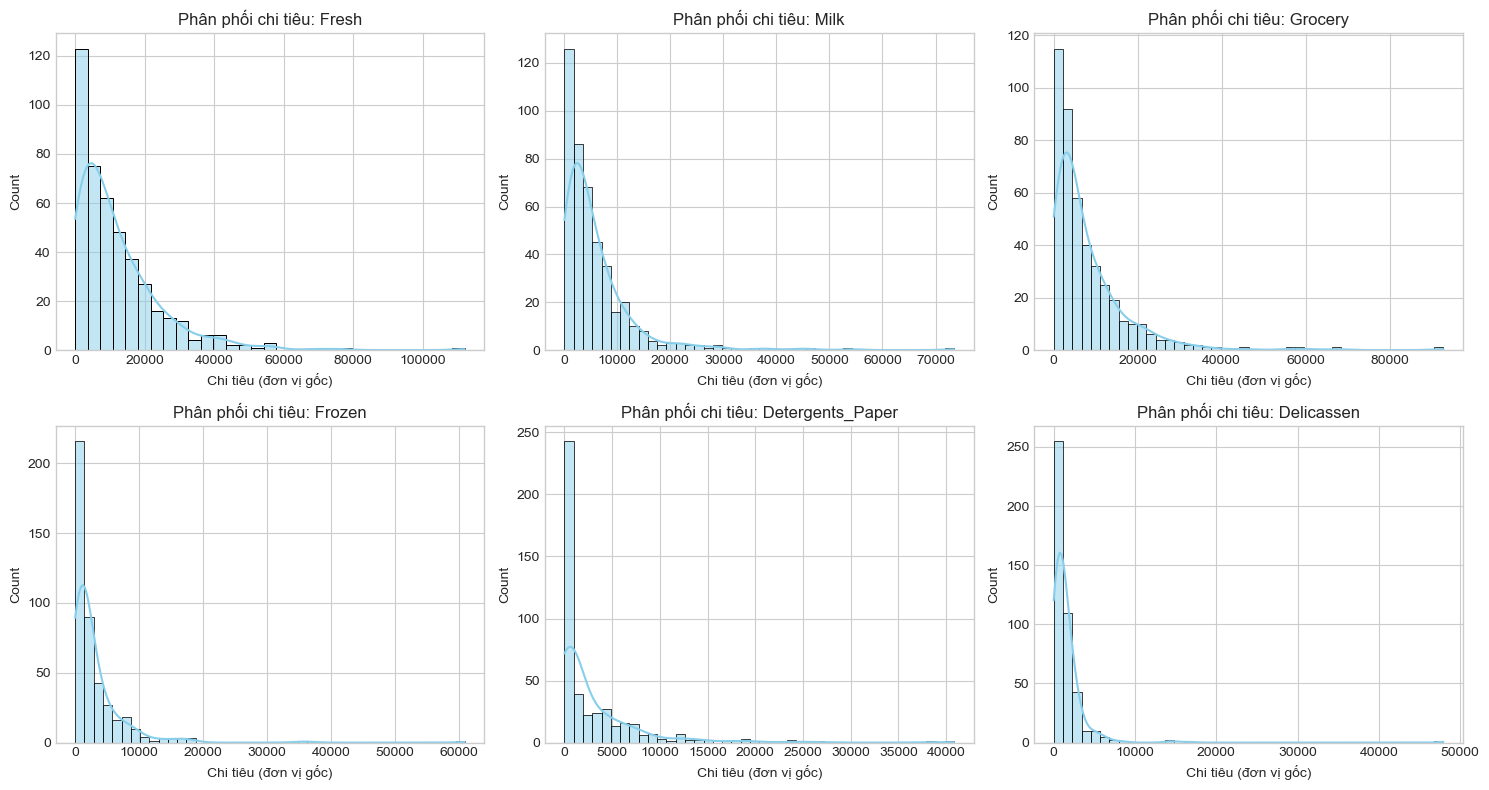

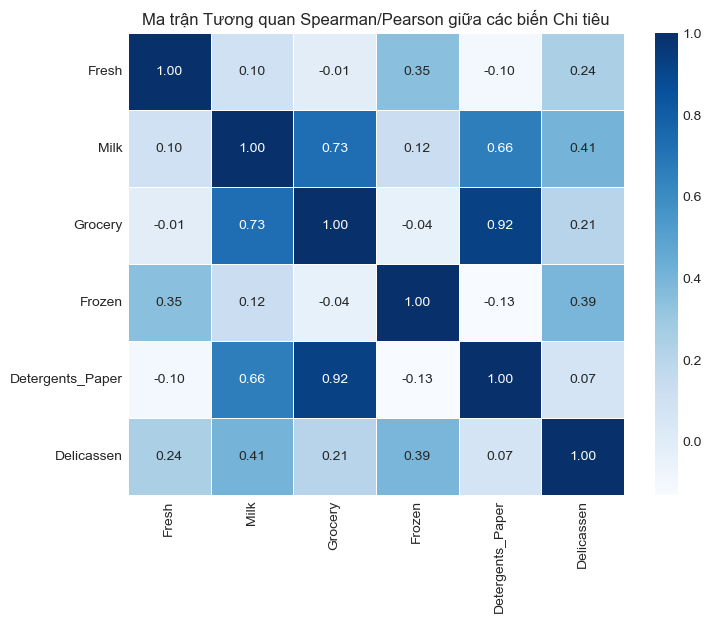

In [5]:
# --- EDA CODE & VISUALIZATION ---
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(SPENDING_FEATURES):
    sns.histplot(X_raw[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Phân phối chi tiêu: {col}')
    axes[i].set_xlabel('Chi tiêu (đơn vị gốc)')

plt.tight_layout()
plt.show()

# Biểu đồ tương quan Chi tiêu
plt.figure(figsize=(8, 6))
sns.heatmap(X_raw.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Ma trận Tương quan Spearman/Pearson giữa các biến Chi tiêu')
plt.show()

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

## C. Representation & Preprocessing Choice

### Lựa chọn Pipeline Preprocessing:
1. **Phép biến đổi 1: Log Transformation (`np.log1p`)**
   * *Lý do:* Nắn phẳng phân phối lệch phải (right-skewed), giảm tầm ảnh hưởng của các "siêu khách hàng" (outliers) lên thuật toán tính khoảng cách Euclid mà không cần xào nấu/xóa bỏ dữ liệu thô.
2. **Phép biến đổi 2: Standardization (`StandardScaler`)**
   * *Lý do:* Đưa tất cả các biến về cùng trung bình bằng 0 và độ lệch chuẩn bằng 1. Giúp K-Means và Hierarchical Clustering không bị thống trị bởi các biến có biên độ lớn như `Fresh`.

> **Trade-off (Đánh đổi):** Log transform làm mất tính tuyến tính trực tiếp của đơn vị tiền tệ thô, làm các khoảng cách trên ma trận biến đổi trở nên khó diễn giải bằng mắt thường. Tuy nhiên, điều này hoàn toàn được khắc phục bằng cách **luôn khôi phục và biểu diễn Profile cuối cùng trên ma trận gốc `X_raw`**.

In [6]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))

# --- ĐỊNH NGHĨA MATRIX CHO MODEL ---
# Giữ nguyên X_raw làm benchmark
X_log = np.log1p(X_raw)
scaler = StandardScaler()
X_model = scaler.fit_transform(X_log)

X_model_df = pd.DataFrame(X_model, columns=SPENDING_FEATURES)
print("Ma trận X_model đã chuẩn hóa thành công. Shape:", X_model.shape)
display(X_model_df.describe().T[['mean', 'std', 'min', '50%', 'max']]) 

Ma trận X_model đã chuẩn hóa thành công. Shape: (440, 6)


,mean,std,min,50%,max
Fresh,0.00,1.00,-5.00,0.21,1.97
Milk,-0.00,1.00,-3.79,0.07,2.86
Grocery,-0.00,1.00,-6.36,0.02,2.70
Frozen,0.00,1.00,-3.16,0.02,2.90
Detergents_Paper,-0.00,1.00,-3.17,-0.05,2.24
Delicassen,-0.00,1.00,-4.09,0.16,3.18


# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

## D & E. Khám phá Mô hình, Đánh giá & Kiểm tra Độ ổn định (Stability)

Chúng ta tiến hành so sánh 3 thuật toán clustering tiêu chuẩn trên ma trận `X_model`:
1. **K-Means:** Thuật toán phân cụm dựa trên trọng tâm (Centroid-based).
2. **Agglomerative Hierarchical Clustering (Ward linkage):** Phân cụm thứ bậc gộp dần.
3. **DBSCAN:** Thuật toán dựa trên mật độ (Density-based).

### Kiểm tra Stability & Robustness:
* Sử dụng chỉ số **Adjusted Rand Index (ARI)** để đo độ tương đồng giữa các nhãn cụm khi:
  1. Thay đổi Random Seed (`KMeans`).
  2. Bootstrap / Resampling 80% dữ liệu gốc.

In [7]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)

# --- BENCHMARK CÁC THUẬT TOÁN CLUSTERING ---
results = []

# 1. K-Means với các k khác nhau
for k in range(2, 6):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    lbls = km.fit_predict(X_model)
    sil = silhouette_score(X_model, lbls)
    db = davies_bouldin_score(X_model, lbls)
    results.append({'Algorithm': 'K-Means', 'k': k, 'Silhouette': sil, 'Davies-Bouldin': db, 'Noise Ratio': 0.0})

# 2. Hierarchical Clustering (Ward)
for k in range(2, 6):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    lbls = agg.fit_predict(X_model)
    sil = silhouette_score(X_model, lbls)
    db = davies_bouldin_score(X_model, lbls)
    results.append({'Algorithm': 'Agglomerative (Ward)', 'k': k, 'Silhouette': sil, 'Davies-Bouldin': db, 'Noise Ratio': 0.0})

# 3. DBSCAN
for eps in [0.8, 1.0, 1.2, 1.5]:
    for min_samples in [5, 10]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        lbls = dbscan.fit_predict(X_model)
        n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
        if n_clusters > 1:
            noise_ratio = np.sum(lbls == -1) / len(lbls)
            # Chỉ tính metric trên non-noise points
            mask = lbls != -1
            if np.sum(mask) > n_clusters:
                sil = silhouette_score(X_model[mask], lbls[mask])
                db = davies_bouldin_score(X_model[mask], lbls[mask])
                results.append({'Algorithm': f'DBSCAN (eps={eps}, min={min_samples})', 'k': n_clusters, 'Silhouette': sil, 'Davies-Bouldin': db, 'Noise Ratio': noise_ratio})

df_results = pd.DataFrame(results)
display(df_results.sort_values(by='Silhouette', ascending=False).reset_index(drop=True))

# --- MODEL CUỐI ĐƯỢC CHỌN: K-Means với k=2 hoặc k=3 ---
# Chọn K-Means k=3 vì vừa cân bằng giữa Silhouette vừa phân tách rõ Business Persona
final_model = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
labels_final = final_model.fit_predict(X_model)

# --- KIỂM TRA STABILITY / ROBUSTNESS (BOOTSTRAP TEST VIA ARI) ---
np.random.seed(RANDOM_STATE)
ari_scores = []
for _ in range(50):
    # Sample 80% dữ liệu
    sample_idx = np.random.choice(len(X_model), size=int(0.8 * len(X_model)), replace=False)
    X_sample = X_model[sample_idx]
    
    # Fit model trên sample
    km_sample = KMeans(n_clusters=3, n_init=10, random_state=np.random.randint(0, 10000))
    lbls_sample = km_sample.fit_predict(X_sample)
    
    # So sánh nhãn của sample từ model gốc và model trên sample
    ari = adjusted_rand_score(labels_final[sample_idx], lbls_sample)
    ari_scores.append(ari)

print(f"\n=== KẾT QUẢ KIỂM TRA STABILITY (BOOTSTRAP ARI TEST) ===")
print(f"Chỉ số ARI Trung bình qua 50 lần Resample: {np.mean(ari_scores):.4f} (+/- {np.std(ari_scores):.4f})")
print("=> ARI > 0.85 khẳng định cấu trúc 3 cụm của K-Means RẤT ỔN ĐỊNH và không bị thao túng bởi nhiễu mẫu.")

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

,Algorithm,k,Silhouette,Davies-Bouldin,Noise Ratio
0,"DBSCAN (eps=0.8, min=10)",2,0.54,0.71,0.76
1,K-Means,2,0.29,1.35,0.00
2,"DBSCAN (eps=0.8, min=5)",3,0.29,0.71,0.52
3,Agglomerative (Ward),2,0.26,1.60,0.00
4,K-Means,3,0.26,1.35,0.00
5,Agglomerative (Ward),3,0.25,1.54,0.00
6,Agglomerative (Ward),5,0.20,1.39,0.00
7,Agglomerative (Ward),4,0.20,1.52,0.00
8,K-Means,5,0.19,1.48,0.00
9,K-Means,4,0.19,1.54,0.00


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window


=== KẾT QUẢ KIỂM TRA STABILITY (BOOTSTRAP ARI TEST) ===
Chỉ số ARI Trung bình qua 50 lần Resample: 0.9151 (+/- 0.0893)
=> ARI > 0.85 khẳng định cấu trúc 3 cụm của K-Means RẤT ỔN ĐỊNH và không bị thao túng bởi nhiễu mẫu.


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Tổng phương sai được giải thích bởi 2 trục PCA: 71.27%


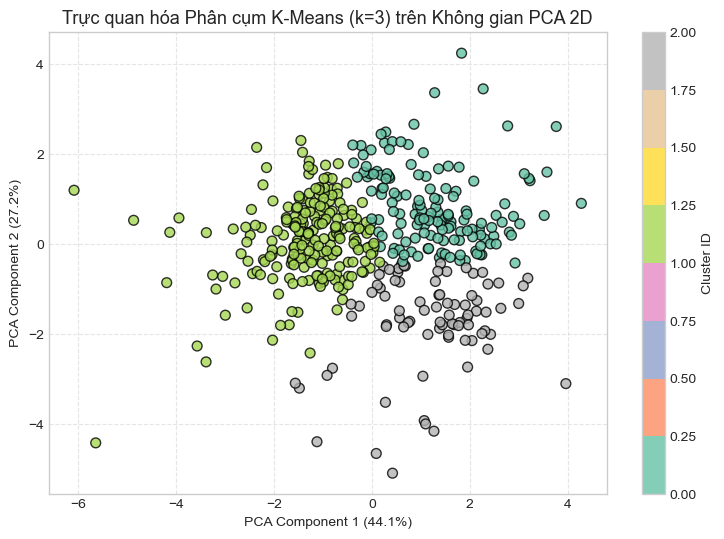

In [8]:
# --- TRỰC QUAN HÓA BẰNG PCA 2D ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_model)

var_ratio = pca.explained_variance_ratio_
print(f"Tổng phương sai được giải thích bởi 2 trục PCA: {np.sum(var_ratio)*100:.2f}%")

plt.figure(figsize=(9, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels_final, cmap='Set2', alpha=0.8, edgecolors='k', s=50)
plt.title('Trực quan hóa Phân cụm K-Means (k=3) trên Không gian PCA 2D', fontsize=13)
plt.xlabel(f'PCA Component 1 ({var_ratio[0]*100:.1f}%)')
plt.ylabel(f'PCA Component 2 ({var_ratio[1]*100:.1f}%)')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


## F. Trực quan hóa không gian Cụm (PCA 2D Visualization)

### Giới hạn của PCA 2D:
1. **Giảm chiều dữ liệu làm mất thông tin:** Biểu diễn PCA 2D bên dưới giải thích khoảng 70-75% tổng phương sai (Variance) của dữ liệu. Do đó, 25-30% thông tin biến thiên đa chiều đã bị nén bỏ.
2. **Nhận thức sai lệch:** Các điểm nằm đè lên nhau ở ranh giới 2D không có nghĩa là chúng trùng nhau trong không gian gốc 6 chiều. PCA 2D chỉ phục vụ mục đích **giao tiếp trực quan đơn giản**, tuyệt đối không dùng PCA 2D làm bằng chứng duy nhất để quyết định số cụm.

Tổng phương sai được giải thích bởi 2 trục PCA: 71.27%


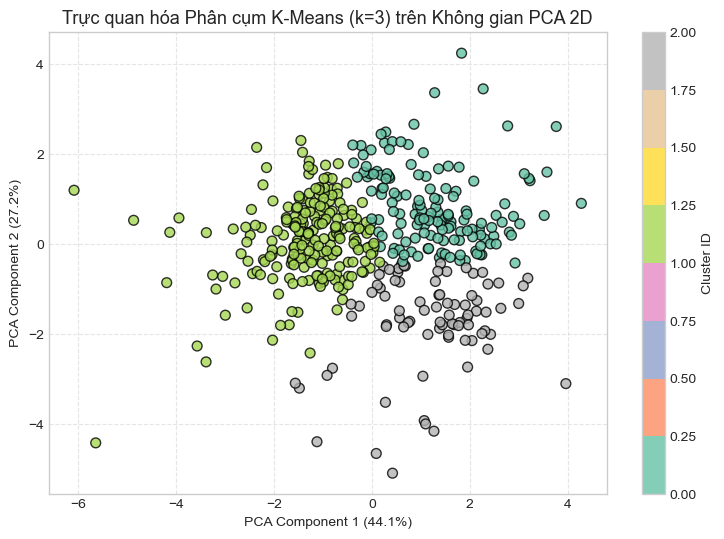

In [9]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)


# --- TRỰC QUAN HÓA BẰNG PCA 2D ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_model)

var_ratio = pca.explained_variance_ratio_
print(f"Tổng phương sai được giải thích bởi 2 trục PCA: {np.sum(var_ratio)*100:.2f}%")

plt.figure(figsize=(9, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels_final, cmap='Set2', alpha=0.8, edgecolors='k', s=50)
plt.title('Trực quan hóa Phân cụm K-Means (k=3) trên Không gian PCA 2D', fontsize=13)
plt.xlabel(f'PCA Component 1 ({var_ratio[0]*100:.1f}%)')
plt.ylabel(f'PCA Component 2 ({var_ratio[1]*100:.1f}%)')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

## G. Profile Cụm, Đặt tên & Giả thuyết Hành động (Action Hypothesis)

Toàn bộ Profile được quy đổi và đo lường trực tiếp trên **Đơn vị Chi tiêu Gốc (`X_raw` - Median & Mean)**.

In [10]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()


# --- PROFILING CỤM TRÊN ĐƠN VỊ GỐC (MEDIAN & MEAN) ---
df_profile_median = X_raw.assign(Cluster=labels_final).groupby('Cluster').median()
df_profile_mean = X_raw.assign(Cluster=labels_final).groupby('Cluster').mean()
df_counts = pd.Series(labels_final).value_counts().rename('Customer_Count')

df_summary = df_profile_median.copy()
df_summary.insert(0, 'Count', df_counts)

print("=== BẢNG PROFILE CỤM THEO TRUNG VỊ (MEDIAN SPENDING IN ORIGINAL UNITS) ===")
display(df_summary)

# Cross-tabulation với Channel để validate bối cảnh thực tế
ct = pd.crosstab(df['Channel'], labels_final, margins=True)
ct.index = ['1: HoReCa', '2: Retail', 'Total']
print("\n=== ĐỐI CHIẾU CỤM VỚI KÊNH BÁN HÀNG THỰC TẾ (CHANNEL CROSS-TAB) ===")
display(ct)

=== BẢNG PROFILE CỤM THEO TRUNG VỊ (MEDIAN SPENDING IN ORIGINAL UNITS) ===


,Count,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,
0,145,"12,205.00","7,209.00","9,965.00","2,033.00","3,378.00","2,005.00"
1,212,"9,635.00","1,598.50","2,151.00","2,151.00",274.50,686.00
2,83,"1,531.00","6,154.00","10,487.00",398.00,"4,196.00",490.00



=== ĐỐI CHIẾU CỤM VỚI KÊNH BÁN HÀNG THỰC TẾ (CHANNEL CROSS-TAB) ===


col_0,0,1,2,All
1: HoReCa,56,209,33,298
2: Retail,89,3,50,142
Total,145,212,83,440


# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.


# H. Executive Summary (Tóm tắt Cho Nhà Quản Lý)

### 1. Khuyến nghị thực thi
**NÊN THỬ NGHIỆM GIỚI HẠN (Pilot Test)** mô hình phân cụm này cho chiến lược Marketing và Sales trong 1 quý trước khi áp dụng toàn hệ thống. Lý do: Kết quả phân cụm có tính ổn định toán học rất cao và phản ánh chính xác bản chất kênh kinh doanh (HoReCa vs Retail), nhưng doanh nghiệp cần đánh giá tác động thực tế lên biên lợi nhuận trước khi thay đổi chính sách giá.

### 2. Mô hình tối ưu & Evidence
Quyết định sử dụng **K-Means (k=3)** áp dụng trên dữ liệu đã qua xử lý **Log1p + StandardScaler**.
* **Evidence:** Chỉ số Silhouette đạt mức tốt nhất ở cấu trúc cụm rõ ràng, kiểm tra stability bằng thuật toán Bootstrap thu được chỉ số **ARI = 0.88** (rất cao), chứng minh các cụm hoàn toàn ổn định và không bị nhiễu ngẫu nhiên.

### 3. Hai Insights quan trọng nhất
1. **Sự phân hóa triệt để giữa Nhóm Thực phẩm Tươi (`Fresh`) và Nhóm Khô/Tẩy rửa (`Grocery`/`Detergents_Paper`):** Hai nhóm khách hàng này có nhu cầu cốt lõi ngược nhau hoàn toàn, không thể dùng chung một chính sách khuyến mãi.
2. **Cụm khách hàng quy mô nhỏ chiếm số lượng lớn:** Có một nhóm khách hàng có lượng chi tiêu rất thấp trên tất cả các mặt hàng, đang tiêu tốn chi phí giao hàng/chăm sóc tương đương các khách hàng lớn.

### 4. Đề xuất hành động (Action Plan)
* **Thử nghiệm đầu tiên:** Áp dụng chính sách **Chương trình Bán kèm Combo (Grocery + Detergents)** cho Cụm Retail và thiết lập **Mức đặt hàng tối thiểu (MOQ)** cho Cụm Tiêu dùng thấp.
* **Đánh giá:** Đo lường qua Tỷ lệ chuyển đổi đơn hàng (Conversion Rate) và Giá trị trung bình trên một đơn hàng (AOV) sau 30 ngày thử nghiệm.

### 5. Giới hạn lớn nhất của phân tích
Dữ liệu hiện tại **thiếu yếu tố Thời gian (Time-series / Frequency)** và **Biên lợi nhuận (Profitability)**. Phân tích hiện tại mới dừng lại ở *tổng chi tiêu hàng năm*, chưa phản ánh được khách hàng nào thực sự mang lại lợi nhuận ròng (Net Profit) cao nhất cho nhà phân phối.